# Monte Carlo Method

The Monte Carlo method is a computational algorithm that relies on repeated random sampling to obtain numerical results. It is often used to solve problems that are deterministic in nature but are difficult to solve analytically. The method is named after the Monte Carlo Casino in Monaco, where random sampling is a common practice.

First let's import the necessary libraries,

In [68]:
import random, math
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon

## 1 - Area of an Irregular Shape

Now let's define our shape,

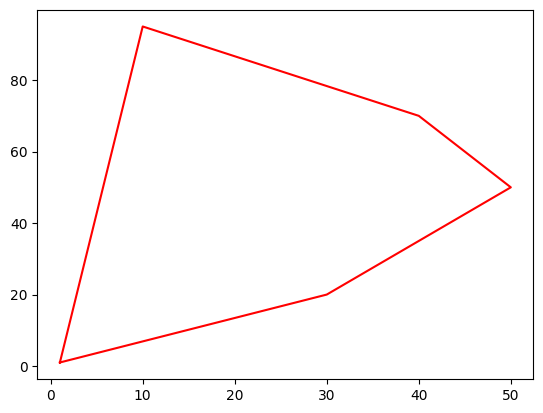

In [69]:
coords = [(1, 1), (10, 95), (40, 70), (50, 50),(30,20)]
map = Polygon(coords) # will use later

# x, y = zip(*coords)
# alternatively, we can find the value of x and y using list comprehension as follows:
x = [coord[0] for coord in coords]
y = [coord[1] for coord in coords]

plt.plot(x + [x[0],], y + [y[0],], color="red")

And finally the algorithm to calculate the area of the shape,

Predicted Area: 2298.0, Actual Area: 2502.5


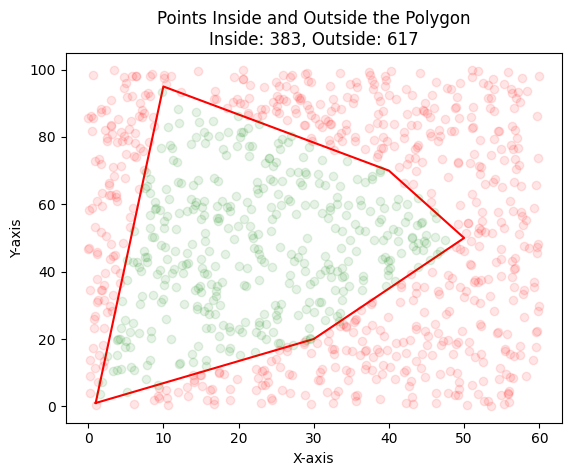

In [70]:
x_point = []
y_point = []

inside = 0
outside = 0

for _ in range(1000):
    x_rand = random.uniform(0, 60)
    y_rand = random.uniform(0, 100)
    point = Point(x_rand, y_rand)
    if map.contains(point):
        inside += 1
        x_point.append(x_rand)
        y_point.append(y_rand)
    else:
        outside += 1
        plt.plot(x_rand, y_rand, 'ro', alpha=0.1)

plt.plot(x + [x[0],], y + [y[0],], color="red")
plt.plot(x_point, y_point, 'go', alpha=0.1)
plt.title(f'Points Inside and Outside the Polygon\nInside: {inside}, Outside: {outside}')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

area_map = map.area
predicted_area = (inside / (inside + outside)) * (60 * 100)
print(f"Predicted Area: {predicted_area}, Actual Area: {area_map}")


## 2 - A Gambling Game

In this game, binary coin are toasted, with two variable, cumulative heads and cumulative tails. You win if the difference between the two is 3, or the game continues!

In [71]:
class GamblingGame:
    def __init__(self):
        self.serial = 0
        self.cum_head = 0
        self.cum_tail = 0

    def run(self):
        while True:
            self.serial += 1
            random_num = random.randint(0, 1)
            if random_num == 0:
                self.cum_head += 1
            else:
                self.cum_tail += 1
            diff = abs(self.cum_head - self.cum_tail)
            if diff == 3:
                return 8 - self.serial


if __name__ == "__main__":
    run = 50
    total_rev = 0

    while run > 0:
        game = GamblingGame()
        total_rev += game.run()
        run -= 1

    print("Total rev : ", total_rev)

Total rev :  -74


## 3 - Numerical Integration

Let's integrate $\int_2^5 x^3 dx$ using the Monte Carlo method. 

In [72]:
def fun(x):
    return x**3

class NumericalIntegration:
    def __init__(self, range_x_in, range_x_out, range_y_in, range_y_out, iteration=50):
        self.inside = 0
        self.outside = 0
        self.iteration = iteration
        self.range_x_in = range_x_in
        self.range_x_out = range_x_out
        self.range_y_in = range_y_in
        self.range_y_out = range_y_out

    def run(self):
        iteration = self.iteration
        while iteration > 0:
            random_num_x = random.uniform(self.range_x_in, self.range_x_out)
            random_num_y = random.uniform(self.range_y_in, self.range_y_out)

            y_real_value = fun(random_num_x)
            if random_num_y <= y_real_value:
                self.inside += 1
            else:
                self.outside += 1
            
            iteration -= 1
    
    def area_approximate(self):
        self.run()

        rectangle_area = (self.range_x_out - self.range_x_in) * (self.range_y_out - self.range_y_in)
        return (self.inside / (self.inside + self.outside) * rectangle_area)

areaFinder = NumericalIntegration(2, 5, 0, 140, 10000)
print(areaFinder.area_approximate())

152.838


## 4 - Estimating Pi

In [73]:
def fun(x):
    return math.sqrt(1-x*x)

class PiEstimation:
    def __init__(self, range_x_in, range_x_out, range_y_in, range_y_out, iteration=50):
        self.inside = 0
        self.outside = 0
        self.iteration = iteration
        self.range_x_in = range_x_in
        self.range_x_out = range_x_out
        self.range_y_in = range_y_in
        self.range_y_out = range_y_out

    def run(self):
        iteration = self.iteration
        while iteration > 0:
            random_num_x = random.random()
            random_num_y = random.random()

            y_real_value = fun(random_num_x)
            if random_num_y <= y_real_value:
                self.inside += 1
            else:
                self.outside += 1
            
            iteration -= 1
    
    def area_approximate(self):
        self.run()
        return (self.inside / (self.inside + self.outside) * 4)

areaFinder = PiEstimation(0, 1, 0, 1, 1000000)
print(areaFinder.area_approximate())

3.144184


## 5 - Random Walk Simulation

Suppose your plane crushed, and want to predict where you will be after 100 steps. According to the wind, you know the probability of going forward, left or right.

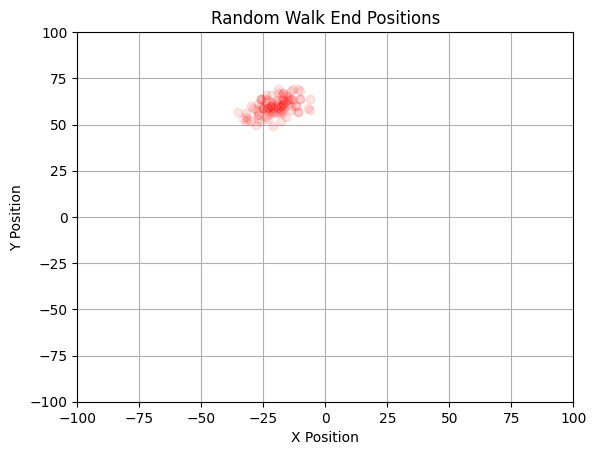

In [74]:
class RandomWalkProblem:
    def __init__(self, step_limit=100):
        self.x_pos = 0
        self.y_pos = 0
        self.step_limit = step_limit
        self.history = [(self.x_pos, self.y_pos)]
    
    def run(self):
        for _ in range(self.step_limit):
            ransom_num = random.randint(0, 9)
            if ransom_num <= 5:
                self.y_pos += 1 # Move up
            elif ransom_num <= 8:
                self.x_pos -= 1 # Move left
            else:
                self.x_pos += 1 # Move right
        return (self.x_pos, self.y_pos)
    
    def plot(self):
        x_vals = [pos[0] for pos in self.history]
        y_vals = [pos[1] for pos in self.history]

        plt.plot(x_vals, y_vals, marker='o')
        plt.title('Random Walk Path')
        plt.xlabel('X Position')
        plt.ylabel('Y Position')
        plt.grid()
        plt.show()

    def multi_run(self, runs=10):
        results = []
        for _ in range(runs):
            result = self.run()
            results.append(result)
            self.x_pos = 0
            self.y_pos = 0
            self.history = [(self.x_pos, self.y_pos)]
        # print("Results of each run: ", results)

        plt.plot([res[0] for res in results], [res[1] for res in results], 'ro', alpha=0.1)
        plt.title('Random Walk End Positions')
        plt.xlabel('X Position')
        plt.ylabel('Y Position')
        plt.xlim(-self.step_limit, self.step_limit)
        plt.ylim(-self.step_limit, self.step_limit)
        plt.grid()
        plt.show()

if __name__ == "__main__":
    walk = RandomWalkProblem(step_limit=100)
    walk.multi_run(100)

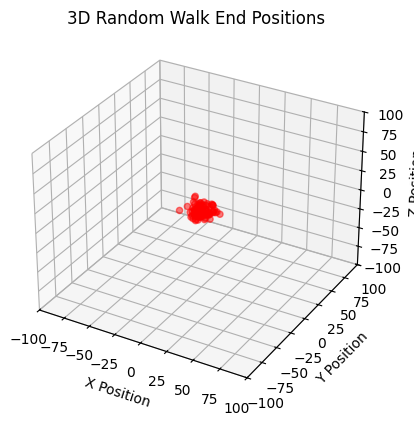

In [81]:

class RandomWalk3D:
    def __init__(self, step_limit=100):
        self.x_pos = 0
        self.y_pos = 0
        self.z_pos = 0
        self.step_limit = step_limit
        self.history = [(self.x_pos, self.y_pos, self.z_pos)]
    
    def run(self):
        for _ in range(self.step_limit):
            random_num = random.randint(0, 5)
            if random_num == 0:
                self.x_pos += 1  # Move right
            elif random_num == 1:
                self.x_pos -= 1  # Move left
            elif random_num == 2:
                self.y_pos += 1  # Move forward
            elif random_num == 3:
                self.y_pos -= 1  # Move backward
            elif random_num == 4:
                self.z_pos += 1  # Move up
            else:
                self.z_pos -= 1  # Move down
            self.history.append((self.x_pos, self.y_pos, self.z_pos))
        return (self.x_pos, self.y_pos, self.z_pos)
    
    def plot(self):
        x_vals = [pos[0] for pos in self.history]
        y_vals = [pos[1] for pos in self.history]
        z_vals = [pos[2] for pos in self.history]

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(x_vals, y_vals, z_vals, marker='o')
        ax.set_title('3D Random Walk Path')
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_zlabel('Z Position')
        plt.show()

    def multi_run(self, runs=10):
        results = []
        for _ in range(runs):
            result = self.run()
            results.append(result)
            self.x_pos = 0
            self.y_pos = 0
            self.z_pos = 0
            self.history = [(self.x_pos, self.y_pos, self.z_pos)]

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter([res[0] for res in results], [res[1] for res in results], [res[2] for res in results], c='r', alpha=0.5)
        ax.set_title('3D Random Walk End Positions')
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_zlabel('Z Position')
        ax.set_xlim(-self.step_limit, self.step_limit)
        ax.set_ylim(-self.step_limit, self.step_limit)
        ax.set_zlim(-self.step_limit, self.step_limit)
        plt.show()

if __name__ == "__main__":
    walk_3d = RandomWalk3D(step_limit=100)
    walk_3d.multi_run(100)

## 6 - Reliability Problem

A manufacturing plant has three bearings that fail according to a probability distribution. When a bearing fails, there is a delay before repair can begin. The plant must decide between two repair strategies:

1. **Single Repair**: Repair only the bearing(s) that have failed
2. **All Repair**: Replace all three bearings whenever any bearing fails

Each strategy has different costs associated with bearing replacement, downtime, and repairman labor. The goal is to simulate both strategies over a 30,000-hour period and determine which strategy minimizes total cost.

In [75]:
class ReliabilityProblem:
    def __init__(self, simulations=1000):
        self.simulations = simulations
        self.bearing_life_probabilities = {
            1000: 0.10,
            1100: 0.14,
            1200: 0.24,
            1300: 0.14,
            1400: 0.12,
            1500: 0.10,
            1600: 0.06,
            1700: 0.05,
            1800: 0.03,
            1900: 0.02,
        }

        self.delay_times_probabilities = {
            4: 0.30,
            6: 0.60,
            8: 0.10,
        }

    def run_single_repair(self, time_limit=30000):
        clock_1 = 0
        clock_2 = 0
        clock_3 = 0
        total_cost = 0

        for _ in range(self.simulations):
            life_1 = self.sample_from_distribution(self.bearing_life_probabilities)
            delay_1 = self.sample_from_distribution(self.delay_times_probabilities)
            clock_1 += life_1
            
            life_2 = self.sample_from_distribution(self.bearing_life_probabilities)
            delay_2 = self.sample_from_distribution(self.delay_times_probabilities)
            clock_2 += life_2 

            life_3 = self.sample_from_distribution(self.bearing_life_probabilities)
            delay_3 = self.sample_from_distribution(self.delay_times_probabilities)
            clock_3 += life_3


            cost_of_bearings = 3 * 20
            
            total_delay = delay_1 + delay_2 + delay_3
            repair_delay = 0
            if clock_1 == clock_2 == clock_3:
                repair_delay += 40 
            elif clock_1 == clock_2 or clock_2 == clock_3 or clock_1 == clock_3:
                repair_delay += 30 + 20
            else:
                repair_delay += 20 + 20 + 20
            downtime_cost = (total_delay + repair_delay) * 5

            # print("Clocks: ", clock_1, clock_2, clock_3, " Lives: ", life_1, life_2, life_3, " Delays: ", delay_1, delay_2, delay_3)
            repairman_cost = repair_delay * 25 / 60
            total_cost += cost_of_bearings + downtime_cost + repairman_cost

            if min(clock_1, clock_2, clock_3) >= time_limit:
                break   
        
        return total_cost
    
    def run_all_repair(self, time_limit=30000):
        clock = 0
        total_delay = 0
        count = 0
        for _ in range(self.simulations):
            count += 1
            life_1 = self.sample_from_distribution(self.bearing_life_probabilities)
            life_2 = self.sample_from_distribution(self.bearing_life_probabilities)
            life_3 = self.sample_from_distribution(self.bearing_life_probabilities)
            clock += min(life_1, life_2, life_3)

            delay = self.sample_from_distribution(self.delay_times_probabilities)
            total_delay += delay
            # print("Clock: ", clock, " Lives: ", life_1, life_2, life_3, " delays: ", delay)

            if clock >= time_limit:
                break
        cost_of_bearings = 3 * count * 20
        downtime_cost = (total_delay + (count * 40)) * 5
        repairman_cost = (count * 40) * 25 / 60
        total_cost = cost_of_bearings + downtime_cost + repairman_cost
        return total_cost

    def sample_from_distribution(self, distribution):
        rand_value = random.random()
        cumulative_probability = 0.0
        for value, probability in distribution.items():
            cumulative_probability += probability
            if rand_value <= cumulative_probability:
                return value
        return value  
    
if __name__ == "__main__":
    problem = ReliabilityProblem(simulations=300000)
    total_cost = problem.run_single_repair(30000)
    print("Total cost for single repair strategy over simulations: ", total_cost)
    total_cost_all_repair = problem.run_all_repair(30000)
    print("Total cost for all repair strategy over simulations: ", total_cost_all_repair)

Total cost for single repair strategy over simulations:  11645.0
Total cost for all repair strategy over simulations:  8486.666666666666


## 7 - Bombing Problem

In [76]:
hit_count = 0
miss_count = 0

for _ in range(1000000):
    x_random = random.uniform(-1.5, 1.5)
    x_val = 500 * x_random
    y_random = random.uniform(-1.5, 1.5)
    y_val = 300 * y_random

    if (abs(x_val) <= 500) and (abs(y_val) <= 300):
        hit_count += 1
    else:
        miss_count += 1

strike_percentage = hit_count / (hit_count + miss_count) * 100
print("Strike Percentage: ", strike_percentage)

Strike Percentage:  44.4178
